In [13]:
import pandas as pd
import numpy as np

df = pd.read_excel("../data/raw/Online Retail.xlsx")

df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df = df.drop_duplicates()
df = df[df["UnitPrice"] > 0]
df = df[df["Quantity"] > 0]  # iadeleri (negatif quantity) şimdilik çıkarıyoruz
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]  # cancelled orders
df = df.dropna(subset=["CustomerID"])  # CustomerID olmayan satırları at

df.shape

(392692, 9)

In [14]:
df["CustomerID"].nunique()

4338

In [15]:
customer_features = df.groupby("CustomerID").agg(
    total_spending=("Revenue", "sum"),
    total_orders=("InvoiceNo", "nunique"),
    unique_products=("StockCode", "nunique")
).reset_index()

customer_features.head()
customer_features.shape

(4338, 4)

In [16]:
df[df["CustomerID"] == 12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [17]:
referance_date = df["InvoiceDate"].max()
referance_date

Timestamp('2011-12-09 12:50:00')

In [18]:
recency_df = df.groupby("CustomerID").agg(
    last_purchase_date=("InvoiceDate", "max")
).reset_index()

recency_df["recency_days"] = (referance_date - recency_df["last_purchase_date"]).dt.days

recency_df.head()

,CustomerID,last_purchase_date,recency_days
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


In [19]:
rfm["avg_order_value"] = rfm["total_spending"] / rfm["total_orders"]
rfm.head()

,CustomerID,total_spending,total_orders,unique_products,last_purchase_date,recency_days,avg_order_value,R_score,F_score,M_score
0,12346.0,77183.60,1,1,2011-01-18 10:01:00,325,77183.600000,1,1,5
1,12347.0,4310.00,7,103,2011-12-07 15:52:00,1,615.714286,5,5,5
2,12348.0,1797.24,4,22,2011-09-25 13:13:00,74,449.310000,2,4,4
3,12349.0,1757.55,1,73,2011-11-21 09:51:00,18,1757.550000,4,1,4
4,12350.0,334.40,1,17,2011-02-02 16:01:00,309,334.400000,1,1,2


In [20]:
rfm = customer_features.merge(recency_df, on="CustomerID")
rfm.head()

,CustomerID,total_spending,total_orders,unique_products,last_purchase_date,recency_days
0,12346.0,77183.60,1,1,2011-01-18 10:01:00,325
1,12347.0,4310.00,7,103,2011-12-07 15:52:00,1
2,12348.0,1797.24,4,22,2011-09-25 13:13:00,74
3,12349.0,1757.55,1,73,2011-11-21 09:51:00,18
4,12350.0,334.40,1,17,2011-02-02 16:01:00,309


In [21]:
rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["total_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["total_spending"], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,CustomerID,total_spending,total_orders,unique_products,last_purchase_date,recency_days,R_score,F_score,M_score
0,12346.0,77183.60,1,1,2011-01-18 10:01:00,325,1,1,5
1,12347.0,4310.00,7,103,2011-12-07 15:52:00,1,5,5,5
2,12348.0,1797.24,4,22,2011-09-25 13:13:00,74,2,4,4
3,12349.0,1757.55,1,73,2011-11-21 09:51:00,18,4,1,4
4,12350.0,334.40,1,17,2011-02-02 16:01:00,309,1,1,2


In [23]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm["log_spending"] = np.log1p(rfm["total_spending"])
rfm["log_orders"] = np.log1p(rfm["total_orders"])
rfm["log_recency"] = np.log1p(rfm["recency_days"])

features = rfm[["log_recency", "log_orders", "log_spending"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 1.40989446, -0.95521426,  3.7077163 ],
       [-2.14649825,  1.07442519,  1.41490344],
       [ 0.38397128,  0.38630445,  0.72002428],
       [-0.57467446, -0.95521426,  0.70228691],
       [ 1.37475812, -0.95521426, -0.61451388]])

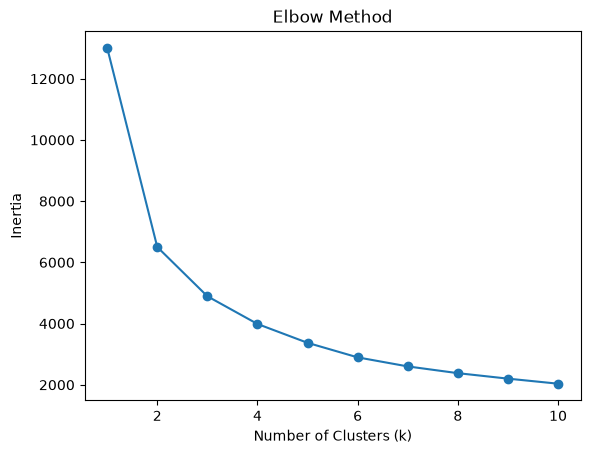

In [24]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [26]:
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster_k4"] = kmeans_k4.fit_predict(scaled_features)

rfm.groupby("cluster_k4").agg(
    customer_count=("CustomerID", "count"),
    avg_recency=("recency_days", "mean"),
    avg_orders=("total_orders", "mean"),
    avg_spending=("total_spending", "mean")
)

,customer_count,avg_recency,avg_orders,avg_spending
cluster_k4,,,,
0,808,17.055693,2.121287,540.346374
1,1642,179.426309,1.319732,347.605470
2,685,10.391241,13.992701,8290.353095
3,1203,67.803824,4.211139,1829.550268


In [27]:
segment_map = {
    2: "High Value",
    0: "Occasional",
    3: "Regular",
    1: "At Risk"
}

rfm["segment"] = rfm["cluster_k4"].map(segment_map)

rfm["segment"].value_counts()

segment
At Risk       1642
Regular       1203
Occasional     808
High Value     685
Name: count, dtype: int64